# BaliMask3D Standardized Pretrained Baseline

# InstantMesh Pretrained Iitialize

In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2: Clone repo + install dependencies
# Jalankan sekali. Setelah selesai, restart runtime kalau diperlukan.
%cd /content/drive/MyDrive/Tugas_Akhir

!rm -rf InstantMesh-clean
!git clone https://github.com/TencentARC/InstantMesh.git InstantMesh-clean

%cd /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean

!pip -q uninstall -y huggingface_hub accelerate diffusers transformers pytorch-lightning lightning-fabric peft rembg cupy cupy-cuda12x cupy-cuda11x jax jaxlib flax chex orbax-checkpoint || true
!pip -q install -U pip setuptools wheel packaging jedi
!pip -q install numpy==1.26.4 scipy pandas openpyxl omegaconf einops
!pip -q install pillow opencv-python imageio imageio-ffmpeg matplotlib plotly trimesh xatlas plyfile PyMCubes
!pip -q install torchmetrics webdataset tensorboard safetensors sentencepiece
!pip -q install huggingface_hub==0.25.2 accelerate==0.27.2 diffusers==0.26.3 transformers==4.38.2
!pip -q install ripser persim ninja
!pip -q install git+https://github.com/NVlabs/nvdiffrast.git --no-build-isolation

print("Setup selesai.")

/content/drive/MyDrive/Tugas_Akhir
Cloning into 'InstantMesh-clean'...
remote: Enumerating objects: 334, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 334 (delta 130), reused 100 (delta 100), pack-reused 158 (from 1)
Receiving objects: 100% (334/334), 33.55 MiB | 39.45 MiB/s, done.
Resolving deltas: 100% (138/138), done.
/content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
optax 0.2.8 requires jax>=0.5.3, which is not installed.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
sentence-transformers 5.4.1 requires huggingface-hub>=0.23.0, which is not installed.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, which is not installed.
cudf-cu12 26.2.1 requires cupy-cuda12x>=13.6.0, which is not installed.
timm 1.0.26 r

In [ ]:
# Cell 3: Verify GPU + nvdiffrast
import sys, importlib.util, torch

print("Python:", sys.version)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")
print("nvdiffrast spec:", importlib.util.find_spec("nvdiffrast"))

import nvdiffrast.torch as dr
print("nvdiffrast OK:", dr)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
nvdiffrast spec: ModuleSpec(name='nvdiffrast', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7df806425070>, origin='/usr/local/lib/python3.12/dist-packages/nvdiffrast/__init__.py', submodule_search_locations=['/usr/local/lib/python3.12/dist-packages/nvdiffrast'])
nvdiffrast OK: <module 'nvdiffrast.torch' from '/usr/local/lib/python3.12/dist-packages/nvdiffrast/torch/__init__.py'>


In [ ]:
# Cell 4: Path configuration
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/Tugas_Akhir')
REPO_ROOT = PROJECT_ROOT / 'InstantMesh-clean'
DATASET_ROOT = PROJECT_ROOT / 'Dataset' / 'BaliMask3D'

# Metadata CSV. Kalau file belum ada di Drive, cell berikutnya bisa upload manual.
METADATA_CSV = DATASET_ROOT / 'metadata' / 'balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split.csv'

OUT_ROOT = PROJECT_ROOT / 'Outputs' / 'baselines' / 'instantmesh_pretrained_balimask3d_standard'
RGBA_INPUT_ROOT = OUT_ROOT / 'rgba_inputs'
INFER_ROOT = OUT_ROOT / 'instantmesh_outputs'
EVAL_ROOT = OUT_ROOT / 'evaluation'
SHOWCASE_ROOT = OUT_ROOT / 'showcase'
LOG_ROOT = OUT_ROOT / 'logs'

for p in [OUT_ROOT, RGBA_INPUT_ROOT, INFER_ROOT, EVAL_ROOT, SHOWCASE_ROOT, LOG_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

assert REPO_ROOT.exists(), REPO_ROOT
assert DATASET_ROOT.exists(), DATASET_ROOT

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPO_ROOT   :", REPO_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("METADATA_CSV:", METADATA_CSV)
print("OUT_ROOT    :", OUT_ROOT)

PROJECT_ROOT: /content/drive/MyDrive/Tugas_Akhir
REPO_ROOT   : /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean
DATASET_ROOT: /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D
METADATA_CSV: /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/metadata/balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split.csv
OUT_ROOT    : /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard


In [ ]:
# Cell 5: Optional upload metadata CSV if not found in Drive
from pathlib import Path

if not METADATA_CSV.exists():
    print("Metadata belum ditemukan di Drive:", METADATA_CSV)
    print("Silakan upload metadata CSV.")
    from google.colab import files
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    tmp_path = Path('/content') / uploaded_name
    METADATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    import shutil
    shutil.copy2(tmp_path, METADATA_CSV)
    print("Copied metadata to:", METADATA_CSV)
else:
    print("Metadata ditemukan:", METADATA_CSV)

Metadata ditemukan: /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/metadata/balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split.csv


In [ ]:
# Cell 6: Write safe helper files
mesh_util_colab_py = REPO_ROOT / 'src' / 'utils' / 'mesh_util_colab.py'
infer_util_colab_py = REPO_ROOT / 'src' / 'utils' / 'infer_util_colab.py'

mesh_util_colab_py.write_text('import os\nimport trimesh\nimport numpy as np\nfrom PIL import Image\n\ndef _to_numpy(x):\n    if isinstance(x, np.ndarray):\n        return x\n    if hasattr(x, "detach"):\n        return x.detach().cpu().numpy()\n    return np.asarray(x)\n\ndef save_obj(pointnp_px3, facenp_fx3, colornp_px3, fpath):\n    pointnp_px3 = _to_numpy(pointnp_px3).astype(np.float32)\n    facenp_fx3 = _to_numpy(facenp_fx3).astype(np.int64)\n    colornp_px3 = _to_numpy(colornp_px3)\n\n    pointnp_px3 = pointnp_px3 @ np.array([[1, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=np.float32)\n    facenp_fx3 = facenp_fx3[:, [2, 1, 0]]\n\n    mesh = trimesh.Trimesh(\n        vertices=pointnp_px3,\n        faces=facenp_fx3,\n        vertex_colors=colornp_px3,\n        process=False,\n    )\n    mesh.export(fpath, "obj")\n\ndef save_obj_with_mtl(pointnp_px3, tcoords_px2, facenp_fx3, facetex_fx3, texmap_hxwx3, fname):\n    pointnp_px3 = _to_numpy(pointnp_px3).astype(np.float32)\n    tcoords_px2 = _to_numpy(tcoords_px2).astype(np.float32)\n    facenp_fx3 = _to_numpy(facenp_fx3).astype(np.int64)\n    facetex_fx3 = _to_numpy(facetex_fx3).astype(np.int64)\n    texmap_hxwx3 = _to_numpy(texmap_hxwx3).astype(np.float32)\n\n    fol, na = os.path.split(fname)\n    na, _ = os.path.splitext(na)\n    os.makedirs(fol, exist_ok=True)\n\n    mtl_path = os.path.join(fol, f"{na}.mtl")\n    obj_path = os.path.join(fol, f"{na}.obj")\n    tex_path = os.path.join(fol, f"{na}.png")\n\n    with open(mtl_path, "w", encoding="utf-8") as fid:\n        fid.write("newmtl material_0\\n")\n        fid.write("Kd 1 1 1\\n")\n        fid.write("Ka 0 0 0\\n")\n        fid.write("Ks 0.4 0.4 0.4\\n")\n        fid.write("Ns 10\\n")\n        fid.write("illum 2\\n")\n        fid.write(f"map_Kd {na}.png\\n")\n\n    with open(obj_path, "w", encoding="utf-8") as fid:\n        fid.write(f"mtllib {na}.mtl\\n")\n        for p in pointnp_px3:\n            fid.write("v %f %f %f\\n" % (p[0], p[1], p[2]))\n        for p in tcoords_px2:\n            fid.write("vt %f %f\\n" % (p[0], p[1]))\n        fid.write("usemtl material_0\\n")\n        for i, f in enumerate(facenp_fx3):\n            f1 = f + 1\n            f2 = facetex_fx3[i] + 1\n            fid.write("f %d/%d %d/%d %d/%d\\n" % (f1[0], f2[0], f1[1], f2[1], f1[2], f2[2]))\n\n    tex = np.clip(texmap_hxwx3 * 255.0, 0, 255).astype(np.uint8)\n    Image.fromarray(tex).save(tex_path)\n', encoding='utf-8')

# Cell 6 revisi: Write safe helper files dengan save_video CUDA-safe
mesh_util_colab_py = REPO_ROOT / 'src' / 'utils' / 'mesh_util_colab.py'
infer_util_colab_py = REPO_ROOT / 'src' / 'utils' / 'infer_util_colab.py'

infer_util_colab_code = r'''import cv2
import imageio
import numpy as np
import torch
from PIL import Image

def remove_background(image, rembg_session=None):
    if rembg_session is None:
        return image
    import rembg
    return rembg.remove(image, session=rembg_session)

def resize_foreground(image, ratio):
    if ratio is None:
        return image
    if isinstance(image, Image.Image):
        image = np.array(image)

    h, w = image.shape[:2]
    alpha = image[..., 3] if image.shape[-1] == 4 else None
    if alpha is None:
        return Image.fromarray(image)

    ys, xs = np.where(alpha > 0)
    if len(xs) == 0 or len(ys) == 0:
        return Image.fromarray(image)

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    fg = image[y0:y1 + 1, x0:x1 + 1]

    side = max(fg.shape[0], fg.shape[1])
    target_side = int(round(side / max(ratio, 1e-6)))
    target_side = max(target_side, side)

    canvas = np.zeros((target_side, target_side, image.shape[2]), dtype=np.uint8)
    oy = (target_side - fg.shape[0]) // 2
    ox = (target_side - fg.shape[1]) // 2
    canvas[oy:oy + fg.shape[0], ox:ox + fg.shape[1]] = fg
    canvas = cv2.resize(canvas, (w, h), interpolation=cv2.INTER_AREA)
    return Image.fromarray(canvas)

def save_video(frames, out_path, fps=8):
    if isinstance(frames, torch.Tensor):
        frames = frames.detach().cpu()

    with imageio.get_writer(str(out_path), fps=fps) as writer:
        for frame in frames:
            if isinstance(frame, torch.Tensor):
                frame = frame.detach().cpu()

            arr = np.asarray(frame)

            # handle CHW -> HWC
            if arr.ndim == 3 and arr.shape[0] in [3, 4]:
                arr = np.transpose(arr, (1, 2, 0))

            if arr.dtype != np.uint8:
                if arr.max() <= 1.0:
                    arr = arr * 255.0
                arr = np.clip(arr, 0, 255).astype(np.uint8)

            writer.append_data(arr)
'''

infer_util_colab_py.write_text(infer_util_colab_code, encoding='utf-8')

print("Wrote:", mesh_util_colab_py)
print("Wrote:", infer_util_colab_py)
print("Wrote:", mesh_util_colab_py)
print("Wrote:", infer_util_colab_py)

Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/mesh_util_colab.py
Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/infer_util_colab.py
Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/mesh_util_colab.py
Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/infer_util_colab.py


In [ ]:
# Cell 7: Write run_colab_patched.py
run_colab_patched_py = REPO_ROOT / 'run_colab_patched.py'
run_colab_patched_py.write_text('import os\nimport argparse\nimport random\nimport numpy as np\nimport torch\nfrom PIL import Image\nfrom torchvision.transforms import v2\nfrom omegaconf import OmegaConf\nfrom einops import rearrange\nfrom tqdm import tqdm\nfrom huggingface_hub import hf_hub_download\nfrom diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler\n\nfrom src.utils.train_util import instantiate_from_config\nfrom src.utils.camera_util import (\n    FOV_to_intrinsics,\n    get_zero123plus_input_cameras,\n    get_circular_camera_poses,\n)\nfrom src.utils.mesh_util_colab import save_obj, save_obj_with_mtl\nfrom src.utils.infer_util_colab import remove_background, resize_foreground, save_video\n\ndef seed_everything(seed: int):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\ndef get_render_cameras(batch_size=1, M=120, radius=4.0, elevation=20.0, is_flexicubes=False):\n    c2ws = get_circular_camera_poses(M=M, radius=radius, elevation=elevation)\n    if is_flexicubes:\n        cameras = torch.linalg.inv(c2ws)\n        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)\n    else:\n        extrinsics = c2ws.flatten(-2)\n        intrinsics = FOV_to_intrinsics(30.0).unsqueeze(0).repeat(M, 1, 1).float().flatten(-2)\n        cameras = torch.cat([extrinsics, intrinsics], dim=-1)\n        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1)\n    return cameras\n\ndef render_frames(model, planes, render_cameras, render_size=512, chunk_size=1, is_flexicubes=False):\n    frames = []\n    for i in tqdm(range(0, render_cameras.shape[1], chunk_size), desc="Render video frames"):\n        if is_flexicubes:\n            frame = model.forward_geometry(\n                planes,\n                render_cameras[:, i:i + chunk_size],\n                render_size=render_size,\n            )["img"]\n        else:\n            frame = model.forward_synthesizer(\n                planes,\n                render_cameras[:, i:i + chunk_size],\n                render_size=render_size,\n            )["images_rgb"]\n        frames.append(frame)\n    return torch.cat(frames, dim=1)[0]\n\ndef main():\n    parser = argparse.ArgumentParser()\n    parser.add_argument("config", type=str)\n    parser.add_argument("input_path", type=str)\n    parser.add_argument("--output_path", type=str, default="outputs/")\n    parser.add_argument("--diffusion_steps", type=int, default=75)\n    parser.add_argument("--seed", type=int, default=42)\n    parser.add_argument("--scale", type=float, default=1.0)\n    parser.add_argument("--distance", type=float, default=4.5)\n    parser.add_argument("--view", type=int, default=6, choices=[4, 6])\n    parser.add_argument("--no_rembg", action="store_true")\n    parser.add_argument("--export_texmap", action="store_true")\n    parser.add_argument("--save_video", action="store_true")\n    parser.add_argument("--image_size", type=int, default=320)\n    parser.add_argument("--fp16_pipeline", action="store_true")\n    args = parser.parse_args()\n\n    seed_everything(args.seed)\n\n    config = OmegaConf.load(args.config)\n    config_name = os.path.basename(args.config).replace(".yaml", "")\n    model_config = config.model_config\n    infer_config = OmegaConf.to_container(config.infer_config, resolve=True)\n\n    is_flexicubes = config_name.startswith("instant-mesh")\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    use_fp16_pipeline = bool(args.fp16_pipeline and device.type == "cuda")\n\n    pipeline = DiffusionPipeline.from_pretrained(\n        "sudo-ai/zero123plus-v1.2",\n        custom_pipeline="zero123plus",\n        torch_dtype=torch.float16 if use_fp16_pipeline else torch.float32,\n    )\n    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(\n        pipeline.scheduler.config,\n        timestep_spacing="trailing",\n    )\n\n    if os.path.exists(config.infer_config.unet_path):\n        unet_ckpt_path = config.infer_config.unet_path\n    else:\n        unet_ckpt_path = hf_hub_download(\n            repo_id="TencentARC/InstantMesh",\n            filename="diffusion_pytorch_model.bin",\n            repo_type="model",\n        )\n\n    state_dict = torch.load(unet_ckpt_path, map_location="cpu")\n    pipeline.unet.load_state_dict(state_dict, strict=True)\n    pipeline = pipeline.to(device)\n\n    model = instantiate_from_config(model_config)\n\n    if os.path.exists(config.infer_config.model_path):\n        model_ckpt_path = config.infer_config.model_path\n    else:\n        model_ckpt_path = hf_hub_download(\n            repo_id="TencentARC/InstantMesh",\n            filename=f"{config_name.replace(\'-\', \'_\')}.ckpt",\n            repo_type="model",\n        )\n\n    state_dict = torch.load(model_ckpt_path, map_location="cpu")["state_dict"]\n    state_dict = {k[14:]: v for k, v in state_dict.items() if k.startswith("lrm_generator.")}\n    model.load_state_dict(state_dict, strict=True)\n    model = model.to(device)\n\n    if is_flexicubes:\n        model.init_flexicubes_geometry(device, fovy=30.0)\n\n    model = model.eval()\n\n    image_path = os.path.join(args.output_path, config_name, "images")\n    mesh_path = os.path.join(args.output_path, config_name, "meshes")\n    video_path = os.path.join(args.output_path, config_name, "videos")\n    os.makedirs(image_path, exist_ok=True)\n    os.makedirs(mesh_path, exist_ok=True)\n    os.makedirs(video_path, exist_ok=True)\n\n    if os.path.isdir(args.input_path):\n        input_files = [\n            os.path.join(args.input_path, f)\n            for f in sorted(os.listdir(args.input_path))\n            if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))\n        ]\n    else:\n        input_files = [args.input_path]\n\n    rembg_session = None\n    if not args.no_rembg:\n        import rembg\n        rembg_session = rembg.new_session()\n\n    outputs = []\n    for image_file in input_files:\n        name = os.path.basename(image_file).split(".")[0]\n        input_image = Image.open(image_file)\n\n        if not args.no_rembg:\n            input_image = remove_background(input_image, rembg_session)\n            input_image = resize_foreground(input_image, 0.85)\n\n        output_image = pipeline(input_image, num_inference_steps=args.diffusion_steps).images[0]\n        output_image.save(os.path.join(image_path, f"{name}.png"))\n\n        images = np.asarray(output_image, dtype=np.float32) / 255.0\n        images = torch.from_numpy(images).permute(2, 0, 1).contiguous().float()\n        images = rearrange(images, "c (n h) (m w) -> (n m) c h w", n=3, m=2)\n        outputs.append({"name": name, "images": images})\n\n    del pipeline\n    if device.type == "cuda":\n        torch.cuda.empty_cache()\n\n    input_cameras = get_zero123plus_input_cameras(batch_size=1, radius=4.0 * args.scale).to(device)\n\n    for sample in outputs:\n        name = sample["name"]\n        images = sample["images"].unsqueeze(0).to(device)\n        images = v2.functional.resize(\n            images,\n            args.image_size,\n            interpolation=3,\n            antialias=True\n        ).clamp(0, 1)\n\n        local_input_cameras = input_cameras.clone()\n        if args.view == 4:\n            indices = torch.tensor([0, 2, 4, 5]).long().to(device)\n            images = images[:, indices]\n            local_input_cameras = local_input_cameras[:, indices]\n\n        with torch.no_grad():\n            planes = model.forward_planes(images, local_input_cameras)\n\n        if device.type == "cuda":\n            torch.cuda.empty_cache()\n\n        mesh_path_idx = os.path.join(mesh_path, f"{name}.obj")\n\n        with torch.no_grad():\n            mesh_out = model.extract_mesh(\n                planes,\n                use_texture_map=args.export_texmap,\n                **infer_config,\n            )\n\n        if args.export_texmap:\n            vertices, faces, uvs, mesh_tex_idx, tex_map = mesh_out\n            save_obj_with_mtl(\n                vertices.data.cpu().numpy(),\n                uvs.data.cpu().numpy(),\n                faces.data.cpu().numpy(),\n                mesh_tex_idx.data.cpu().numpy(),\n                tex_map.permute(1, 2, 0).data.cpu().numpy(),\n                mesh_path_idx,\n            )\n        else:\n            vertices, faces, vertex_colors = mesh_out\n            save_obj(vertices, faces, vertex_colors, mesh_path_idx)\n\n        if args.save_video:\n            render_size = infer_config.get("render_resolution", 384)\n            render_cameras = get_render_cameras(\n                batch_size=1,\n                M=120,\n                radius=args.distance,\n                elevation=20.0,\n                is_flexicubes=is_flexicubes,\n            ).to(device)\n\n            frames = render_frames(\n                model,\n                planes,\n                render_cameras=render_cameras,\n                render_size=render_size,\n                chunk_size=1,\n                is_flexicubes=is_flexicubes,\n            )\n            save_video(frames, os.path.join(video_path, f"{name}.mp4"), fps=30)\n\nif __name__ == "__main__":\n    main()\n', encoding='utf-8')
print("Wrote:", run_colab_patched_py)

Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_patched.py


In [ ]:
# Cell 8: Verify syntax
import py_compile

py_compile.compile(str(mesh_util_colab_py), doraise=True)
py_compile.compile(str(infer_util_colab_py), doraise=True)
py_compile.compile(str(run_colab_patched_py), doraise=True)

print("Syntax check OK.")

Syntax check OK.


In [ ]:
# Cell 9: Imports
import os
import sys
import random
import subprocess
import shutil

import numpy as np
import pandas as pd
from PIL import Image

import torch
import trimesh
from scipy.spatial import cKDTree
from tqdm.auto import tqdm
from ripser import ripser
from persim import wasserstein

import matplotlib as mpl
mpl.rcParams["text.usetex"] = False
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from IPython.display import Video, display

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

Torch: 2.10.0+cu128 | CUDA: True


In [ ]:
# Cell 10: Experiment config — max quality, test-only
IM_CONFIG = REPO_ROOT / 'configs' / 'instant-mesh-large.yaml'

SPLIT_TO_RUN = 'test'

NO_REMBG = True
SAVE_VIDEO = True

# Kalau mau visual OBJ berwarna/texture, ubah True
EXPORT_TEXMAP = True

# Untuk rerun max quality, lebih aman False dulu
SKIP_EXISTING_OUTPUT = False

# Quality config
DIFFUSION_STEPS = 100
IM_SCALE = 1.0
IM_DISTANCE = 4.5
IM_VIEW = 6
IMAGE_SIZE = 384

USE_FP16_PIPELINE = True

# Execution switches
RUN_SMOKE_TEST = False
RUN_FULL_BATCH = True
RUN_EVALUATION = True

# Evaluation config — standardized with TripoSR/Wonder3D
N_SAMPLE_POINTS = 10000
N_CD = N_SAMPLE_POINTS

N_TMD_POINTS = 1024
N_TMD = N_TMD_POINTS

NORMALIZE_POINTS_FOR_EVAL = True
TMD_MAXDIM = 1
TMD_THRESH = 1.5

print("SPLIT_TO_RUN:", SPLIT_TO_RUN)
print("DIFFUSION_STEPS:", DIFFUSION_STEPS)
print("IM_VIEW:", IM_VIEW)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("SAVE_VIDEO:", SAVE_VIDEO)
print("EXPORT_TEXMAP:", EXPORT_TEXMAP)
print("RUN_FULL_BATCH:", RUN_FULL_BATCH)
print("RUN_EVALUATION:", RUN_EVALUATION)
print("N_SAMPLE_POINTS:", N_SAMPLE_POINTS)
print("N_TMD_POINTS:", N_TMD_POINTS)
print("NORMALIZE_POINTS_FOR_EVAL:", NORMALIZE_POINTS_FOR_EVAL)

SPLIT_TO_RUN: test
DIFFUSION_STEPS: 100
IM_VIEW: 6
IMAGE_SIZE: 384
SAVE_VIDEO: True
EXPORT_TEXMAP: True
RUN_FULL_BATCH: True
RUN_EVALUATION: True
N_SAMPLE_POINTS: 10000
N_TMD_POINTS: 1024
NORMALIZE_POINTS_FOR_EVAL: True


In [ ]:
# Cell 11: Read metadata CSV and filter test split
metadata_df = pd.read_csv(METADATA_CSV)

# ---- BaliMask3D final metadata adapter ----
# Final metadata columns use view_id + gt_mesh_path. Older baseline cells expect view_index + mesh_src_path.
metadata_df = metadata_df.copy()
if 'view_index' not in metadata_df.columns and 'view_id' in metadata_df.columns:
    metadata_df['view_index'] = metadata_df['view_id']
if 'mesh_src_path' not in metadata_df.columns and 'gt_mesh_path' in metadata_df.columns:
    metadata_df['mesh_src_path'] = metadata_df['gt_mesh_path']
if 'camera_json_path' not in metadata_df.columns and 'camera_json' in metadata_df.columns:
    metadata_df['camera_json_path'] = metadata_df['camera_json']
if 'depth_vis_path' not in metadata_df.columns and 'depth_path' in metadata_df.columns:
    metadata_df['depth_vis_path'] = metadata_df['depth_path']
if 'normal_png_path' not in metadata_df.columns and 'normal_path' in metadata_df.columns:
    metadata_df['normal_png_path'] = metadata_df['normal_path']
metadata_df['mask_id'] = metadata_df['mask_id'].astype(str)
metadata_df['view_name'] = metadata_df['view_name'].astype(str)
metadata_df['split'] = metadata_df['split'].astype(str).str.lower()
print('Adapter OK. Columns now include:', [c for c in ['view_index','mesh_src_path','depth_vis_path','normal_png_path','camera_json_path'] if c in metadata_df.columns])


print("Metadata shape:", metadata_df.shape)
print("Columns:", metadata_df.columns.tolist())
display(metadata_df.head())

required_cols = ['split', 'mask_id', 'view_name', 'rgb_path', 'mask_path', 'mesh_src_path']
missing = [c for c in required_cols if c not in metadata_df.columns]
if missing:
    raise ValueError(f"Kolom metadata kurang: {missing}")

test_df = metadata_df[metadata_df['split'].astype(str).str.lower() == SPLIT_TO_RUN.lower()].copy()
test_df['mask_id'] = test_df['mask_id'].astype(str)
test_df['view_name'] = test_df['view_name'].astype(str)

print("Split counts:")
display(metadata_df['split'].value_counts())

print("Rows selected:", len(test_df))
display(test_df.head())

Adapter OK. Columns now include: ['view_index', 'mesh_src_path', 'depth_vis_path', 'normal_png_path', 'camera_json_path']
Metadata shape: (972, 28)
Columns: ['mask_id', 'view_id', 'view_name', 'radius_used', 'rgb_path', 'mask_path', 'depth_path', 'depth_exr_path', 'normal_path', 'depth_stats_path', 'camera_json', 'camera_dn_json', 'gt_mesh_path', 'ok_rgb', 'ok_mask', 'ok_depth', 'ok_depth_exr', 'ok_normal', 'ok_stats', 'ok_camera', 'ok_mesh', 'ok_all', 'split', 'view_index', 'mesh_src_path', 'camera_json_path', 'depth_vis_path', 'normal_png_path']


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,ok_stats,ok_camera,ok_mesh,ok_all,split,view_index,mesh_src_path,camera_json_path,depth_vis_path,normal_png_path
0,1,0,000.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
1,1,1,001.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,1,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
2,1,2,002.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,2,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
3,1,3,003.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,3,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
4,1,4,004.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,4,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...


Split counts:


,count
split,
train,756
test,108
val,108


Rows selected: 108


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,ok_stats,ok_camera,ok_mesh,ok_all,split,view_index,mesh_src_path,camera_json_path,depth_vis_path,normal_png_path
0,1,0,000.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
1,1,1,001.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,1,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
2,1,2,002.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,2,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
3,1,3,003.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,3,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...
4,1,4,004.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,True,True,test,4,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...


In [ ]:
# Cell 12: Remap local metadata paths to Colab/Drive paths
LOCAL_DATASET_PREFIXES = [
    '/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D',
    '/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D/',
]

def remap_path_to_colab(path_value):
    if pd.isna(path_value):
        return ''
    s = str(path_value).replace('\\', '/')
    for prefix in LOCAL_DATASET_PREFIXES:
        prefix_norm = prefix.rstrip('/')
        if s.startswith(prefix_norm):
            rel = s[len(prefix_norm):].lstrip('/')
            return str(DATASET_ROOT / rel)
    # Kalau sudah path Colab/Drive, biarkan.
    if s.startswith('/content/') or s.startswith('/kaggle/') or s.startswith('/mnt/'):
        return s
    # Fallback: coba treat sebagai path relatif di DATASET_ROOT.
    return str(DATASET_ROOT / s.lstrip('/'))

path_cols = [
    'rgb_path',
    'mask_path',
    'depth_npy_path',
    'depth_vis_path',
    'normal_png_path',
    'mesh_src_path',
    'camera_json_path',
]

for col in path_cols:
    if col in test_df.columns:
        test_df[col + '_colab'] = test_df[col].apply(remap_path_to_colab)

test_df['rgba_input_path'] = test_df.apply(
    lambda r: str(RGBA_INPUT_ROOT / str(r['mask_id']) / str(r['view_name'])),
    axis=1
)

test_df['pred_output_dir'] = test_df.apply(
    lambda r: str(INFER_ROOT / str(r['mask_id']) / Path(str(r['view_name'])).stem),
    axis=1
)

# Validate essential files.
test_df['rgb_exists'] = test_df['rgb_path_colab'].apply(lambda p: Path(p).exists())
test_df['mask_exists'] = test_df['mask_path_colab'].apply(lambda p: Path(p).exists())
test_df['gt_exists'] = test_df['mesh_src_path_colab'].apply(lambda p: Path(p).exists())

print("File availability:")
print("RGB exists :", int(test_df['rgb_exists'].sum()), "/", len(test_df))
print("Mask exists:", int(test_df['mask_exists'].sum()), "/", len(test_df))
print("GT exists  :", int(test_df['gt_exists'].sum()), "/", len(test_df))

missing_df = test_df[~(test_df['rgb_exists'] & test_df['mask_exists'] & test_df['gt_exists'])].copy()
if len(missing_df):
    print("Ada file missing. Contoh:")
    display(missing_df[['mask_id', 'view_name', 'rgb_path_colab', 'mask_path_colab', 'mesh_src_path_colab', 'rgb_exists', 'mask_exists', 'gt_exists']].head(10))
    raise FileNotFoundError("Masih ada path metadata yang gagal diremap. Cek DATASET_ROOT / LOCAL_DATASET_PREFIXES.")

test_manifest_csv = OUT_ROOT / 'metadata_test_remapped.csv'
test_df.to_csv(test_manifest_csv, index=False)
print("Saved:", test_manifest_csv)
display(test_df.head())

File availability:
RGB exists : 108 / 108
Mask exists: 108 / 108
GT exists  : 108 / 108
Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/metadata_test_remapped.csv


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,mask_path_colab,depth_vis_path_colab,normal_png_path_colab,mesh_src_path_colab,camera_json_path_colab,rgba_input_path,pred_output_dir,rgb_exists,mask_exists,gt_exists
0,1,0,000.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True
1,1,1,001.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True
2,1,2,002.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True
3,1,3,003.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True
4,1,4,004.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True


In [ ]:
# Cell 13: Build RGBA for test rows only
def build_rgba_image(rgb_path: Path, mask_path: Path, out_path: Path):
    rgb = Image.open(rgb_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    rgba = np.dstack([np.array(rgb), np.array(mask)])
    out_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(rgba).save(out_path)

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Build RGBA test only'):
    build_rgba_image(
        Path(row['rgb_path_colab']),
        Path(row['mask_path_colab']),
        Path(row['rgba_input_path'])
    )

test_df['rgba_exists'] = test_df['rgba_input_path'].apply(lambda p: Path(p).exists())
test_df.to_csv(test_manifest_csv, index=False)

print("RGBA exists:", int(test_df['rgba_exists'].sum()), "/", len(test_df))
display(test_df.head())

Build RGBA test only:   0%|          | 0/108 [00:00<?, ?it/s]

RGBA exists: 108 / 108


,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,depth_vis_path_colab,normal_png_path_colab,mesh_src_path_colab,camera_json_path_colab,rgba_input_path,pred_output_dir,rgb_exists,mask_exists,gt_exists,rgba_exists
0,1,0,000.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True,True
1,1,1,001.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True,True
2,1,2,002.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True,True
3,1,3,003.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True,True
4,1,4,004.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,True,True,True,True


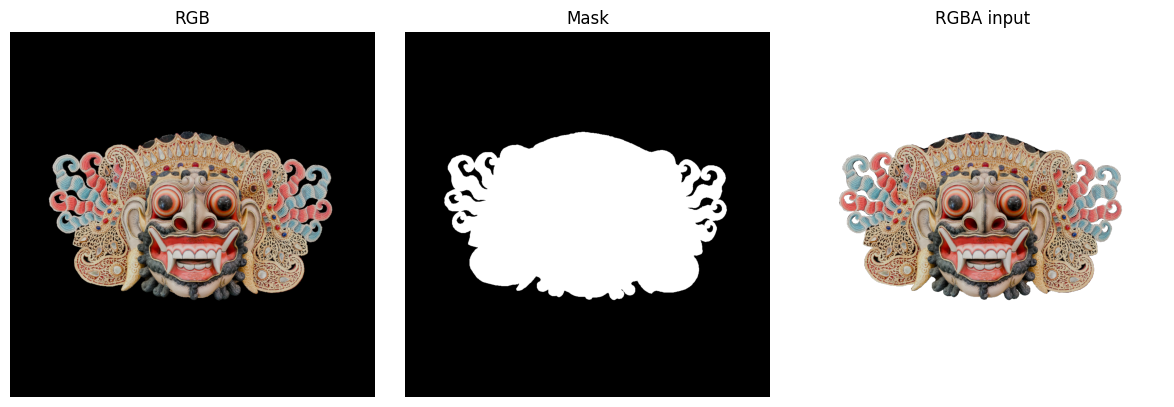

Sample: 1 000.png


In [ ]:
# Cell 14: Preview one test sample
preview_row = test_df.iloc[0]

rgb = Image.open(preview_row['rgb_path_colab']).convert('RGB')
mask = Image.open(preview_row['mask_path_colab']).convert('L')
rgba = Image.open(preview_row['rgba_input_path']).convert('RGBA')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rgb); axes[0].set_title('RGB')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(rgba); axes[2].set_title('RGBA input')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Sample:", preview_row['mask_id'], preview_row['view_name'])

In [ ]:
# Cell 15: Inference helper
def find_instantmesh_outputs(output_path: Path):
    obj_files = sorted((Path(output_path)).rglob('*.obj'))
    mp4_files = sorted((Path(output_path)).rglob('*.mp4'))
    png_files = sorted((Path(output_path)).rglob('*.png'))
    return {
        'mesh_obj': str(obj_files[0]) if obj_files else '',
        'video_mp4': str(mp4_files[0]) if mp4_files else '',
        'mv_image': str(png_files[0]) if png_files else '',
    }

def run_instantmesh_single(rgba_input_path: Path, output_path: Path):
    output_path.mkdir(parents=True, exist_ok=True)

    existing = find_instantmesh_outputs(output_path)
    if SKIP_EXISTING_OUTPUT and existing['mesh_obj'] and Path(existing['mesh_obj']).exists():
        return {
            'returncode': 0,
            'log_path': '',
            'stdout_tail': '',
            'stderr_tail': '',
            'ok': True,
            **existing
        }

    cmd = [
        sys.executable,
        'run_colab_patched.py',
        str(IM_CONFIG),
        str(rgba_input_path),
        '--output_path', str(output_path),
        '--diffusion_steps', str(DIFFUSION_STEPS),
        '--seed', str(SEED),
        '--scale', str(IM_SCALE),
        '--distance', str(IM_DISTANCE),
        '--view', str(IM_VIEW),
        '--image_size', str(IMAGE_SIZE),
    ]

    if USE_FP16_PIPELINE:
        cmd.append('--fp16_pipeline')
    if NO_REMBG:
        cmd.append('--no_rembg')
    if SAVE_VIDEO:
        cmd.append('--save_video')
    if EXPORT_TEXMAP:
        cmd.append('--export_texmap')

    log_path = LOG_ROOT / f"{output_path.parent.name}_{output_path.name}.log"

    print('[RUN]', ' '.join(cmd))
    proc = subprocess.run(cmd, cwd=str(REPO_ROOT), capture_output=True, text=True)

    log_path.write_text(
        '[STDOUT]\n' + (proc.stdout or '') + '\n\n[STDERR]\n' + (proc.stderr or ''),
        encoding='utf-8',
        errors='ignore'
    )

    outputs = find_instantmesh_outputs(output_path)

    return {
        'returncode': proc.returncode,
        'log_path': str(log_path),
        'stdout_tail': (proc.stdout or '')[-3000:],
        'stderr_tail': (proc.stderr or '')[-3000:],
        'ok': proc.returncode == 0 and bool(outputs['mesh_obj']),
        **outputs,
    }

In [ ]:
# Cell 16: Smoke test on first test row
if RUN_SMOKE_TEST:
    smoke_row = test_df.iloc[0]
    smoke_out_dir = Path(smoke_row['pred_output_dir'])

    smoke_result = run_instantmesh_single(
        Path(smoke_row['rgba_input_path']),
        smoke_out_dir
    )

    smoke_df = pd.DataFrame([{**smoke_row.to_dict(), **smoke_result}])
    smoke_csv = OUT_ROOT / 'smoke_test_result.csv'
    smoke_df.to_csv(smoke_csv, index=False)

    display(smoke_df)

    if not smoke_result['ok']:
        print('Smoke test gagal. Cek log:', smoke_result['log_path'])
        print(smoke_result['stderr_tail'])
        raise RuntimeError('Smoke test gagal. Perbaiki dulu sebelum full batch.')
    else:
        print('Smoke test sukses.')
        if smoke_result['video_mp4'] and Path(smoke_result['video_mp4']).exists():
            display(Video(smoke_result['video_mp4'], embed=True))
else:
    print("RUN_SMOKE_TEST=False")

RUN_SMOKE_TEST=False


In [ ]:
# Cell 17: Full batch inference — test rows only
batch_records = []

if RUN_FULL_BATCH:
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='InstantMesh test-only batch'):
        out_dir = Path(row['pred_output_dir'])
        try:
            result = run_instantmesh_single(Path(row['rgba_input_path']), out_dir)
            batch_records.append({**row.to_dict(), **result})
        except Exception as e:
            batch_records.append({
                **row.to_dict(),
                'returncode': -1,
                'log_path': '',
                'stdout_tail': '',
                'stderr_tail': str(e),
                'ok': False,
                'mesh_obj': '',
                'video_mp4': '',
                'mv_image': '',
            })

    pred_df = pd.DataFrame(batch_records)
else:
    pred_df = pd.DataFrame()
    print("RUN_FULL_BATCH=False")

pred_manifest_csv = OUT_ROOT / 'test_predictions.csv'
pred_df.to_csv(pred_manifest_csv, index=False)

print("Saved:", pred_manifest_csv)
display(pred_df.head() if len(pred_df) else pred_df)

InstantMesh test-only batch:   0%|          | 0/108 [00:00<?, ?it/s]

[RUN] /usr/bin/python3 run_colab_patched.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/rgba_inputs/1/000.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/instantmesh_outputs/1/000 --diffusion_steps 100 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 384 --fp16_pipeline --no_rembg --save_video --export_texmap
[RUN] /usr/bin/python3 run_colab_patched.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/rgba_inputs/1/001.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/instantmesh_outputs/1/001 --diffusion_steps 100 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 384 --fp16_p

,mask_id,view_id,view_name,radius_used,rgb_path,mask_path,depth_path,depth_exr_path,normal_path,depth_stats_path,...,gt_exists,rgba_exists,returncode,log_path,stdout_tail,stderr_tail,ok,mesh_obj,video_mp4,mv_image
0,1,0,000.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,,"▌ | 79/120 [00:12<00:06, 6.45it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...
1,1,1,001.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,,"▌ | 79/120 [00:12<00:06, 6.43it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...
2,1,2,002.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,,"▌ | 79/120 [00:12<00:06, 6.44it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...
3,1,3,003.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,,"▌ | 79/120 [00:12<00:06, 6.44it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...
4,1,4,004.png,3.0,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,/home/birhasani/Tugas_Akhir/Dataset/BaliMask3D...,...,True,True,0,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,,"▌ | 79/120 [00:12<00:06, 6.43it/s]\nRender ...",True,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...


In [ ]:
# Cell 18: Evaluation helpers
def load_mesh_safe(mesh_path: Path):
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(tuple(g for g in mesh.geometry.values()))
    return mesh

def sample_points_from_mesh(mesh_path: Path, n=5000):
    mesh = load_mesh_safe(mesh_path)
    pts, _ = trimesh.sample.sample_surface(mesh, n)
    return np.asarray(pts, dtype=np.float32)

def chamfer_distance(a, b):
    tree_a = cKDTree(a)
    tree_b = cKDTree(b)
    dist_ab, _ = tree_b.query(a, k=1)
    dist_ba, _ = tree_a.query(b, k=1)
    return float(dist_ab.mean() + dist_ba.mean())

def hausdorff_distance(a, b):
    tree_a = cKDTree(a)
    tree_b = cKDTree(b)
    dist_ab, _ = tree_b.query(a, k=1)
    dist_ba, _ = tree_a.query(b, k=1)
    return float(max(dist_ab.max(), dist_ba.max()))

def topology_morphology_distance(a, b):
    dg_a = ripser(a, maxdim=1)['dgms'][1]
    dg_b = ripser(b, maxdim=1)['dgms'][1]
    if len(dg_a) == 0 and len(dg_b) == 0:
        return 0.0
    return float(wasserstein(dg_a, dg_b, matching=False))

In [ ]:
# Cell 19: Run evaluation — test predictions only
metrics_rows = []

if RUN_EVALUATION:
    if len(pred_df) == 0:
        pred_manifest_csv = OUT_ROOT / 'test_predictions.csv'
        pred_df = pd.read_csv(pred_manifest_csv)

    ok_pred_df = pred_df[pred_df['ok'] == True].copy()

    for _, row in tqdm(ok_pred_df.iterrows(), total=len(ok_pred_df), desc='Evaluate test CD/UHD/TMD'):
        pred_mesh = Path(str(row['mesh_obj']))
        gt_mesh = Path(str(row['mesh_src_path_colab']))

        rec = {
            'split': row['split'],
            'mask_id': row['mask_id'],
            'view_name': row['view_name'],
            'view_index': row['view_index'],
            'is_front_view': row.get('is_front_view', ''),
            'pred_mesh_path': str(pred_mesh),
            'gt_mesh_path': str(gt_mesh),
            'video_mp4': row.get('video_mp4', ''),
            'rgb_path': row['rgb_path_colab'],
            'ok': False,
            'cd': np.nan,
            'uhd': np.nan,
            'tmd': np.nan,
        }

        try:
            if pred_mesh.exists() and gt_mesh.exists():
                pred_pts = sample_points_from_mesh(pred_mesh)
                gt_pts = sample_points_from_mesh(gt_mesh)

                rec['cd'] = chamfer_distance(pred_pts, gt_pts)
                rec['uhd'] = hausdorff_distance(pred_pts, gt_pts)
                rec['tmd'] = topology_morphology_distance(pred_pts, gt_pts)
                rec['ok'] = True
        except Exception as e:
            rec['error'] = str(e)

        metrics_rows.append(rec)

    metrics_df = pd.DataFrame(metrics_rows)
else:
    metrics_df = pd.DataFrame()
    print("RUN_EVALUATION=False")

metrics_csv = EVAL_ROOT / 'metrics_test_only.csv'
metrics_xlsx = EVAL_ROOT / 'metrics_test_only.xlsx'

metrics_df.to_csv(metrics_csv, index=False)
with pd.ExcelWriter(metrics_xlsx) as writer:
    metrics_df.to_excel(writer, index=False, sheet_name='per_sample')
    if len(metrics_df):
        metrics_df.groupby('mask_id')[['cd', 'uhd', 'tmd']].mean().reset_index().to_excel(writer, index=False, sheet_name='per_mask')
        metrics_df.groupby('view_name')[['cd', 'uhd', 'tmd']].mean().reset_index().to_excel(writer, index=False, sheet_name='per_view')

print("Saved:", metrics_csv)
print("Saved:", metrics_xlsx)
display(metrics_df.head() if len(metrics_df) else metrics_df)

Evaluate test CD/UHD/TMD:   0%|          | 0/108 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/evaluation/metrics_test_only.csv
Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/evaluation/metrics_test_only.xlsx


,split,mask_id,view_name,view_index,is_front_view,pred_mesh_path,gt_mesh_path,video_mp4,rgb_path,ok,cd,uhd,tmd
0,test,1,000.png,0,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.365676,0.563515,4.150796
1,test,1,001.png,1,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.376285,0.654303,4.980267
2,test,1,002.png,2,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.431071,0.844573,5.727788
3,test,1,003.png,3,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.413357,0.823943,5.184601
4,test,1,004.png,4,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.401144,0.809903,4.049681


In [ ]:
# Cell 20: Summary and rank 3 best / 3 worst
if len(metrics_df):
    valid_df = metrics_df[metrics_df['ok'] == True].copy()

    print("Overall mean:")
    display(valid_df[['cd', 'uhd', 'tmd']].mean().to_frame('mean'))

    print("Per mask:")
    display(valid_df.groupby('mask_id')[['cd', 'uhd', 'tmd']].mean().reset_index().sort_values('cd'))

    print("Per view:")
    display(valid_df.groupby('view_name')[['cd', 'uhd', 'tmd']].mean().reset_index().sort_values('cd'))

    ranked_df = valid_df.sort_values('cd').reset_index(drop=True)
    best3_df = ranked_df.head(3).copy()
    worst3_df = ranked_df.tail(3).copy().sort_values('cd', ascending=False)

    best3_df.to_csv(SHOWCASE_ROOT / 'best3_test.csv', index=False)
    worst3_df.to_csv(SHOWCASE_ROOT / 'worst3_test.csv', index=False)

    print("Best 3:")
    display(best3_df)

    print("Worst 3:")
    display(worst3_df)
else:
    print("Metrics belum tersedia.")

Overall mean:


,mean
cd,0.454176
uhd,0.763874
tmd,7.301985


Per mask:


,mask_id,cd,uhd,tmd
0,1,0.399797,0.745662,6.639957
1,21,0.427865,0.798006,7.882189
2,4,0.534866,0.747955,7.383807


Per view:


,view_name,cd,uhd,tmd
22,022.png,0.342934,0.706496,7.861709
16,016.png,0.374584,0.690500,6.842420
18,018.png,0.379331,0.654850,6.542253
35,035.png,0.384000,0.655807,7.216729
19,019.png,0.395095,0.688726,7.958081
33,033.png,0.401474,0.699389,5.963224
20,020.png,0.405982,0.704561,6.502922
17,017.png,0.409472,0.690740,7.670420
1,001.png,0.410766,0.668345,7.370432
34,034.png,0.416782,0.705969,7.283124


Best 3:


,split,mask_id,view_name,view_index,is_front_view,pred_mesh_path,gt_mesh_path,video_mp4,rgb_path,ok,cd,uhd,tmd
0,test,21,019.png,19,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.282992,0.774194,5.756286
1,test,21,018.png,18,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.285211,0.682350,7.352686
2,test,21,017.png,17,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.291614,0.685956,7.111091


Worst 3:


,split,mask_id,view_name,view_index,is_front_view,pred_mesh_path,gt_mesh_path,video_mp4,rgb_path,ok,cd,uhd,tmd
107,test,4,012.png,12,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.702048,0.972508,4.588960
106,test,4,011.png,11,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.699761,0.989476,5.399802
105,test,4,013.png,13,,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.643637,0.900015,7.011874


In [ ]:
# Cell 21: Interactive 3D helper
def show_mesh_plotly(mesh_path: Path, title='Mesh preview', max_faces=250000):
    mesh = load_mesh_safe(mesh_path)
    v = np.asarray(mesh.vertices)
    f = np.asarray(mesh.faces)

    if len(f) > max_faces:
        idx = np.random.choice(len(f), size=max_faces, replace=False)
        f = f[idx]

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=v[:, 0],
                y=v[:, 1],
                z=v[:, 2],
                i=f[:, 0],
                j=f[:, 1],
                k=f[:, 2],
                opacity=1.0
            )
        ]
    )
    fig.update_layout(
        title=title,
        scene_aspectmode='data',
        width=700,
        height=650,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

In [ ]:
# Cell 22: Showcase 3 best — RGB + video + interactive 3D
if len(metrics_df):
    ranked_df = metrics_df[metrics_df['ok'] == True].sort_values('cd').reset_index(drop=True)
    best3_df = ranked_df.head(3).copy()

    print("=== 3 BEST TEST SAMPLES ===")
    for idx, row in best3_df.iterrows():
        print(f"Rank {idx + 1} | mask={row['mask_id']} | view={row['view_name']} | CD={row['cd']:.6f} | UHD={row['uhd']:.6f} | TMD={row['tmd']:.6f}")

        rgb = Image.open(row['rgb_path']).convert('RGB')
        plt.figure(figsize=(4, 4))
        plt.imshow(rgb)
        plt.title(f"BEST #{idx + 1} | mask {row['mask_id']} | {row['view_name']}")
        plt.axis('off')
        plt.show()

        if row.get('video_mp4', '') and Path(row['video_mp4']).exists():
            display(Video(row['video_mp4'], embed=True))

        show_mesh_plotly(
            Path(row['pred_mesh_path']),
            title=f"BEST #{idx + 1} | mask {row['mask_id']} | {row['view_name']}"
        )
else:
    print("Metrics belum tersedia.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Cell 23: Showcase 3 worst — RGB + video + interactive 3D
if len(metrics_df):
    ranked_df = metrics_df[metrics_df['ok'] == True].sort_values('cd').reset_index(drop=True)
    worst3_df = ranked_df.tail(3).copy().sort_values('cd', ascending=False).reset_index(drop=True)

    print("=== 3 WORST TEST SAMPLES ===")
    for idx, row in worst3_df.iterrows():
        print(f"Rank {idx + 1} | mask={row['mask_id']} | view={row['view_name']} | CD={row['cd']:.6f} | UHD={row['uhd']:.6f} | TMD={row['tmd']:.6f}")

        rgb = Image.open(row['rgb_path']).convert('RGB')
        plt.figure(figsize=(4, 4))
        plt.imshow(rgb)
        plt.title(f"WORST #{idx + 1} | mask {row['mask_id']} | {row['view_name']}")
        plt.axis('off')
        plt.show()

        if row.get('video_mp4', '') and Path(row['video_mp4']).exists():
            display(Video(row['video_mp4'], embed=True))

        show_mesh_plotly(
            Path(row['pred_mesh_path']),
            title=f"WORST #{idx + 1} | mask {row['mask_id']} | {row['view_name']}"
        )
else:
    print("Metrics belum tersedia.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Cell 24: Save compact run summary
summary = {
    'metadata_csv': str(METADATA_CSV),
    'split': SPLIT_TO_RUN,
    'test_rows': int(len(test_df)),
    'out_root': str(OUT_ROOT),
    'diffusion_steps': int(DIFFUSION_STEPS),
    'view': int(IM_VIEW),
    'image_size': int(IMAGE_SIZE),
    'save_video': bool(SAVE_VIDEO),
    'export_texmap': bool(EXPORT_TEXMAP),
}

summary_path = OUT_ROOT / 'run_summary.json'
import json
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print("Saved:", summary_path)
print(json.dumps(summary, indent=2))

Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/run_summary.json
{
  "metadata_csv": "/content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/metadata/balimask3d_bali36_rgb_mask_depth_normal_exact_rgb_setup_split.csv",
  "split": "test",
  "test_rows": 108,
  "out_root": "/content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard",
  "diffusion_steps": 100,
  "view": 6,
  "image_size": 384,
  "save_video": true,
  "export_texmap": true
}


In [ ]:

# Cell: Standard comparison export
# Menyalin metrics utama ke lokasi standar agar bisa digabung antar model.
from pathlib import Path
import pandas as pd

standard_eval_dir = OUT_ROOT / 'standard_eval'
standard_eval_dir.mkdir(parents=True, exist_ok=True)

candidate_metrics = [
    OUT_ROOT / 'evaluation' / 'metrics.csv',
    OUT_ROOT / 'test_metrics.csv',
    OUT_ROOT / 'metrics.csv',
    OUT_ROOT / 'wonder3d_metrics.csv',
    OUT_ROOT / 'instantmesh_metrics.csv',
    OUT_ROOT / 'triposr_metrics.csv',
    OUT_ROOT / 'evaluation' / 'test_metrics.csv',
]
# fallback recursive search
candidate_metrics += sorted(OUT_ROOT.rglob('*metrics*.csv'))

src_metric = next((p for p in candidate_metrics if Path(p).exists()), None)
print('OUT_ROOT:', OUT_ROOT)
print('Found metric CSV:', src_metric)

if src_metric is not None:
    dfm = pd.read_csv(src_metric)
    dfm['model_name'] = 'instantmesh_pretrained_balimask3d_standard'
    out_csv = standard_eval_dir / 'instantmesh_pretrained_balimask3d_standard_metrics_standard.csv'
    dfm.to_csv(out_csv, index=False)
    print('Saved standard metrics:', out_csv)
    display(dfm.head())
    num_cols = [c for c in ['cd','uhd','tmd','silhouette_iou','normal_cosine','ssim','lpips'] if c in dfm.columns]
    if num_cols:
        display(dfm.groupby('model_name')[num_cols].mean(numeric_only=True))
else:
    print('Belum ada metrics CSV. Jalankan inference + evaluation cells terlebih dahulu.')


OUT_ROOT: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard
Found metric CSV: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/evaluation/metrics_test_only.csv
Saved standard metrics: /content/drive/MyDrive/Tugas_Akhir/Outputs/baselines/instantmesh_pretrained_balimask3d_standard/standard_eval/instantmesh_pretrained_balimask3d_standard_metrics_standard.csv


,split,mask_id,view_name,view_index,is_front_view,pred_mesh_path,gt_mesh_path,video_mp4,rgb_path,ok,cd,uhd,tmd,model_name
0,test,1,000.png,0,NaN,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.365676,0.563515,4.150796,instantmesh_pretrained_balimask3d_standard
1,test,1,001.png,1,NaN,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.376285,0.654303,4.980267,instantmesh_pretrained_balimask3d_standard
2,test,1,002.png,2,NaN,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.431071,0.844573,5.727788,instantmesh_pretrained_balimask3d_standard
3,test,1,003.png,3,NaN,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.413357,0.823943,5.184601,instantmesh_pretrained_balimask3d_standard
4,test,1,004.png,4,NaN,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Outputs/bas...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,0.401144,0.809903,4.049681,instantmesh_pretrained_balimask3d_standard


,cd,uhd,tmd
model_name,,,
instantmesh_pretrained_balimask3d_standard,0.454176,0.763874,7.301985
